# Advanced Machine Learning – Natural Language Processing
By: **Ivan Runov** & **Sebastiaan Craens** (group 8)

### Practical Assignment 2:

### Imports

In [1]:
import os
import pandas as pd
import re
import matplotlib.pyplot as plt
import numpy as np
import json
from collections import Counter

from tokenizers import Tokenizer # main object for tokenization
from tokenizers.models import BPE # model implementing Byte Pair Encoding.
from tokenizers.trainers import BpeTrainer # trains the BPE vocabulary
from tokenizers.pre_tokenizers import Whitespace # simple pre-tokenizer splitting on spaces

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer

### Settings

In [211]:
DIR_DATA = "data"
DIR_TEXTS = os.path.join(DIR_DATA, "texts")
FILE_METADATA = os.path.join(DIR_DATA, "metadata.csv")

### Loading the texts

In [212]:
# Open metadata file
metadata = pd.read_csv(FILE_METADATA)
metadata.head()

,url,title,reading_level,ebook_no,language,release_date,most_recently_updated,downloads,plaintext_url
0,https://books.flotwiskunde.nl/ebooks/84.html,"Frankenstein; Or, The Modern Prometheus",Reading ease score: 65.0 (8th & 9th grade). Ne...,84,English,"Oct 1, 1993","Sep 8, 2025",145303 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/84.txt
1,https://books.flotwiskunde.nl/ebooks/2701.html,"Moby Dick; Or, The Whale",Reading ease score: 73.3 (7th grade). Fairly e...,2701,English,"Jul 1, 2001","Sep 11, 2025",115857 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/270...
2,https://books.flotwiskunde.nl/ebooks/1342.html,Pride and Prejudice,Reading ease score: 69.2 (8th & 9th grade). Ne...,1342,English,"Jun 1, 1998","Sep 22, 2025",85439 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/134...
3,https://books.flotwiskunde.nl/ebooks/1513.html,Romeo and Juliet,Reading ease score: 92.6 (5th grade). Very eas...,1513,English,"Nov 1, 1998","Sep 18, 2025",71504 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/151...
4,https://books.flotwiskunde.nl/ebooks/26184.html,Simple Sabotage Field Manual,Reading ease score: 60.5 (8th & 9th grade). Ne...,26184,English,"Aug 4, 2008","Feb 5, 2025",59188 downloads in the last 30 days.,https://books.flotwiskunde.nl/ebooks/books/261...


In [213]:
# Create book list DataFrame and load texts into memory
book_list = pd.DataFrame({
    "id": metadata["ebook_no"].astype(int),
    "reading_ease_score": metadata["reading_level"].astype(str).str.extract(r'Reading ease score: (\d+.\d+)', expand=False),
    "title": metadata["title"],
    "file_size_bytes": pd.Series([os.path.getsize(os.path.join(DIR_TEXTS, f"{ebook_no}.txt")) for ebook_no in metadata["ebook_no"]]).astype(int),
    "text_raw": pd.Series([open(os.path.join(DIR_TEXTS, f"{ebook_no}.txt"), "r", encoding="utf-8").read() for ebook_no in metadata["ebook_no"]]),
}).set_index("id")
book_list.head()

,reading_ease_score,title,file_size_bytes,text_raw
id,,,,
84,65.0,"Frankenstein; Or, The Modern Prometheus",456666,﻿The Project Gutenberg eBook of Frankenstein; ...
2701,73.3,"Moby Dick; Or, The Whale",1298616,"﻿The Project Gutenberg eBook of Moby Dick; Or,..."
1342,69.2,Pride and Prejudice,787340,﻿The Project Gutenberg eBook of Pride and Prej...
1513,92.6,Romeo and Juliet,175193,﻿The Project Gutenberg eBook of Romeo and Juli...
26184,60.5,Simple Sabotage Field Manual,77101,﻿The Project Gutenberg eBook of Simple Sabotag...


### Cleaning the texts

In [214]:

# Retain only the text between the Project Gutenberg header and footer
BOOK_START_REGEX = re.compile(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK .+ \*\*\*")
BOOK_END_REGEX = re.compile(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK .+ \*\*\*")
ILLUSTRATION_REGEX = re.compile(r"\[ILLUSTRATION\]")
REFERENCE_REGEX = re.compile(r"\[\d+\]")
CHAPTER_HEADING_REGEX = re.compile(r"(?im)^\s*chapter\s+([ivxlcdm]+|\d+)\b.*$")

# Check that all texts contain the header and footer
assert book_list["text_raw"].map(lambda text: bool(BOOK_START_REGEX.search(text))).all(), "Some texts are missing the Project Gutenberg header"
assert book_list["text_raw"].map(lambda text: bool(BOOK_END_REGEX.search(text))).all(), "Some texts are missing the Project Gutenberg footer"

total_illustations_removed = 0
total_references_removed = 0
total_chapter_headings_removed = 0

for text_id in book_list.index:
    
    text: str = book_list.loc[text_id, "text_raw"]
    
    # Find the header and footer using regex, check that they exist
    start_match = BOOK_START_REGEX.search(text)
    end_match = BOOK_END_REGEX.search(text)
    if not start_match or not end_match:
        raise ValueError("Text is missing the Project Gutenberg header or footer")
    
    # Clean header and footer
    text = text[start_match.end():end_match.start()].strip()
    
    # Clean illustrations ([ILLUSTRATION]) TODO: Why is this not working. I swear I saw this exact string in one of the books.
    total_illustations_removed += len(ILLUSTRATION_REGEX.findall(text))
    text = ILLUSTRATION_REGEX.sub("", text)
    
    # Clean references ([1], [2], etc.)
    total_references_removed += len(REFERENCE_REGEX.findall(text))
    text = REFERENCE_REGEX.sub("", text)
    
    # Chapter headings (roman numerals + digits)
    total_chapter_headings_removed += len(CHAPTER_HEADING_REGEX.findall(text))
    text = CHAPTER_HEADING_REGEX.sub("", text)
    
    # Lowercase everything
    text = text.lower()
    
    book_list.loc[text_id, "text"] = text

print(f"Removed Project Gutenberg headers and footers, {total_illustations_removed} illustrations, {total_references_removed} references, and {total_chapter_headings_removed} chapter headings from the texts.")

Removed Project Gutenberg headers and footers, 0 illustrations, 2609 references, and 5177 chapter headings from the texts.


### Examining some statistics about the corpus

Books with the largest vocabularies:


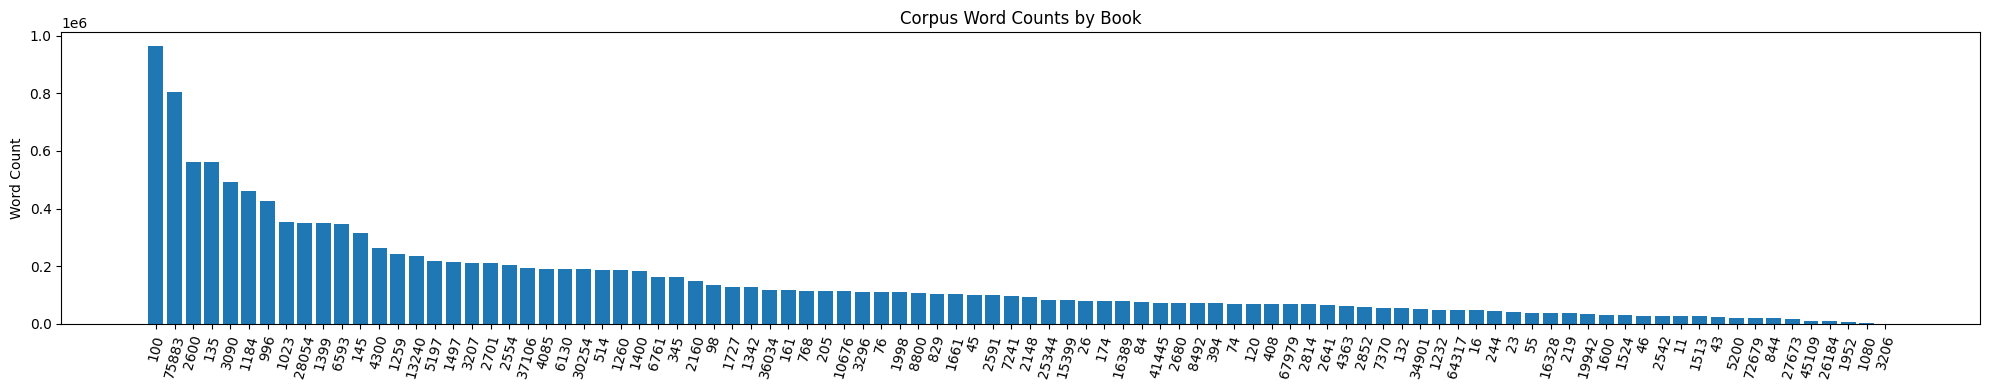

In [215]:
# Split texts into words and compute some statistics about the corpus
book_list["words"] = book_list["text"].map(lambda text: text.split())
book_list["word_count"] = book_list["words"].map(len)
book_list["vocab_size"] = book_list["words"].map(lambda words: len(set(words)))
book_list["relative_vocab_size"] = book_list["vocab_size"] / book_list["word_count"]
book_list["corpus_word_share"] = book_list["word_count"] / book_list["word_count"].sum()

print(f"Books with the largest vocabularies:")
book_list.sort_values('vocab_size', ascending=False)[['title', 'vocab_size', "word_count", "relative_vocab_size"]].head()

# Plot the distribution of token counts across the corpus
plt.figure(figsize=(20, 4))
book_list_sorted = book_list.sort_values("word_count", ascending=False)
plt.bar(book_list_sorted.index.astype(str), book_list_sorted["word_count"])
plt.xticks(rotation=75)
plt.ylabel("Word Count")
plt.title("Corpus Word Counts by Book")
plt.tight_layout()
plt.show()

In [216]:
# Compute the frequency of each token across the entire corpus
all_tokens = [token for words in book_list["words"] for token in words]
token_counts = pd.Series(all_tokens).value_counts().rename_axis("token").reset_index(name="count")
print(f"Total unique tokens in the corpus: {token_counts.shape[0]}")
print(f"Most common tokens in the corpus:")
token_counts.head(10)

Total unique tokens in the corpus: 426152
Most common tokens in the corpus:


,token,count
0,the,712075
1,and,452426
2,of,396962
3,to,362495
4,a,268358
5,in,234857
6,i,193366
7,he,177948
8,that,158151
9,was,154071


In [217]:
singular_tokens = token_counts[token_counts["count"] == 1]
print(f"Number of singular tokens in the corpus: {singular_tokens.shape[0]} ({singular_tokens.shape[0] / token_counts.shape[0]:.2%} of all unique tokens)")
print(f"Sample of singular tokens:")
print(singular_tokens.sample(10))

Number of singular tokens in the corpus: 249193 (58.48% of all unique tokens)
Sample of singular tokens:
                 token  count
316631     determined_      1
185161      verdicts.”      1
333243       _homespun      1
264981   somewhere....      1
336987       _grurin_;      1
198591  shakespeare’s,      1
331944           leger      1
249013          lubeat      1
323390           esope      1
186713     servants,—a      1


C:\Users\SJGMC\AppData\Local\Temp\ipykernel_9884\1464752058.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


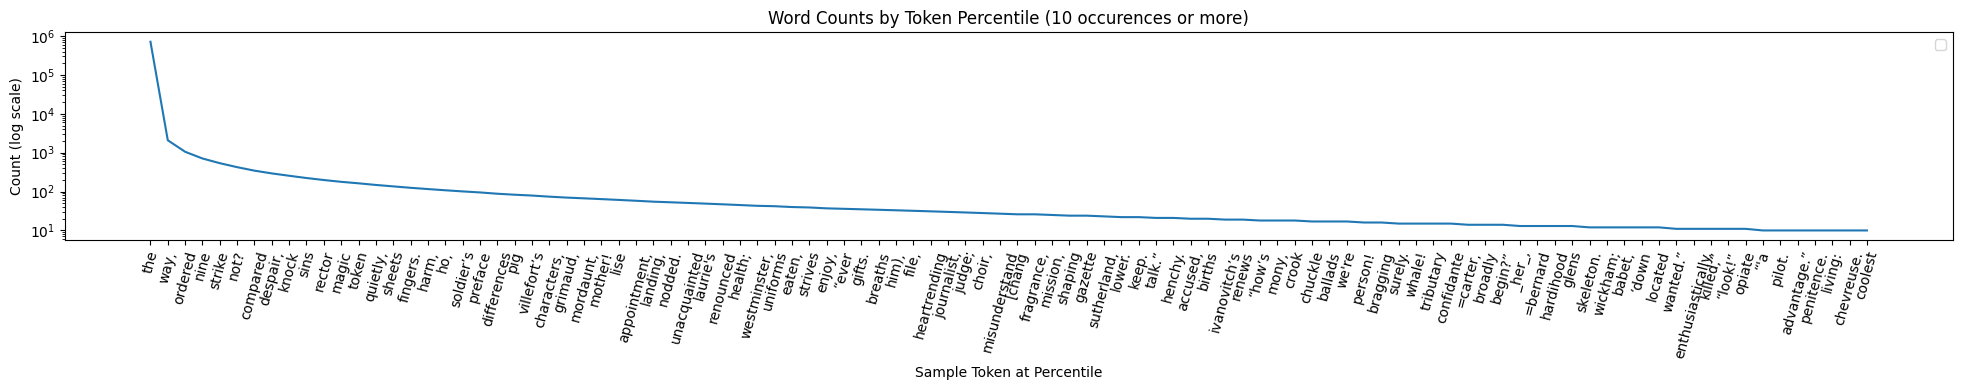

In [218]:
# Plot the distribution of token counts across the corpus
MIN_OCCURRENCES = 10
token_counts_filtered = token_counts[token_counts["count"] >= MIN_OCCURRENCES]
N_SAMPLES = 100

sample_idxs = np.linspace(0, token_counts_filtered.shape[0] - 1, N_SAMPLES).astype(int)
plt.figure(figsize=(20, 4))
plt.plot(token_counts_filtered["token"].iloc[sample_idxs], token_counts_filtered["count"].iloc[sample_idxs])
plt.xlabel("Sample Token at Percentile")
plt.xticks(rotation=75)
plt.ylabel("Count (log scale)")
plt.title("Word Counts by Token Percentile (10 occurences or more)")
plt.tight_layout()
plt.yscale("log")
plt.legend()
plt.show()

In [219]:
# For performance down the line, we keep only the tokens that occur at least 10 times in the corpus for the rest of the notebook
# Create a set of valid tokens for O(1) lookup
valid_tokens_set = set(token_counts[token_counts["count"] >= MIN_OCCURRENCES]["token"].values)

# Filter the original corpus list while maintaining order
filtered_tokens = [token for token in all_tokens if token in valid_tokens_set]

print(f"Total tokens after filtering for minimum occurrences: {len(filtered_tokens)} ({len(filtered_tokens) / len(all_tokens):.2%} of all tokens)")

Total tokens after filtering for minimum occurrences: 13053583 (94.92% of all tokens)


In [ ]:
# Save the cleaned corpus as one text file
with open(os.path.join(DIR_DATA, "cleaned_corpus.txt"), "w", encoding="utf-8") as f:
    f.write(" ".join(filtered_tokens))

### Tokenization

In [220]:
tokenizer = Tokenizer(BPE())           # BPE model with unknown token
tokenizer.pre_tokenizer = Whitespace() # Split text by spaces first

In [221]:
# Training the tokenizer on the corpus.
corpus = book_list["text"].tolist()
VOCAB_SIZE = 10000 # Educated guess based on the number of unique tokens and the long tail distribution of token counts
MIN_FREQUENCY = 10 # Minimum frequency for a token to be included in the vocabulary, based on the distribution of token counts and the large number of singular tokens in the corpus
SPECIAL_TOKENS = [] # No special tokens for now, but we could add [UNK], [PAD], etc. if needed
END_OF_WORD_SUFFIX = "</w>" # Suffix to indicate the end of a word, commonly used in BPE tokenization to distinguish between subword tokens and whole word tokens
trainer = BpeTrainer(vocab_size=VOCAB_SIZE, min_frequency=MIN_FREQUENCY, special_tokens=SPECIAL_TOKENS, end_of_word_suffix=END_OF_WORD_SUFFIX)
tokenizer.train_from_iterator(corpus, trainer=trainer)

In [222]:
vocab_df = pd.DataFrame(tokenizer.get_vocab().items(), columns=["token", "id"]).sort_values("id").reset_index(drop=True)
print(f"Sample of the learned BPE vocabulary:")
print(vocab_df.sample(10))

Sample of the learned BPE vocabulary:
               token    id
8053             sne  8053
7610        sink</w>  7610
6954      habits</w>  6954
9998          flouri  9998
1987        wood</w>  1987
9637  antipholus</w>  9637
7549        pine</w>  7549
6667           bewil  6667
1006      things</w>  1006
7990     outward</w>  7990


In [223]:
print(f"Encoding some sample words using the trained BPE tokenizer:")
for words in ["bathroom", "scientology", "lowest"]:
    print(f"    {words:<11} => {'-'.join(tokenizer.encode(words).tokens)}")

Encoding some sample words using the trained BPE tokenizer:
    bathroom    => ba-th-room</w>
    scientology => sci-ent-o-logy</w>
    lowest      => lo-west</w>


In [224]:
# Save then trained tokenizer
tokenizer.save("bpe_tokenizer.json")
# Save the encoded corpus (could take a couple minutes)
encoded_corpus = tokenizer.encode(" ".join(corpus))
with open("encoded_text.json", "w") as f:
    json.dump(encoded_corpus.ids, f)

In [225]:
# Reload the data
with open("encoded_text.json") as f:
    tokens = json.load(f)
    
print(f"Loaded {len(tokens)} tokens:")
print(  ', '.join([str(token) for token in tokens[:10]]) + ', ...')

Loaded 18997010 tokens:
1046, 3642, 1157, 381, 252, 397, 260, 366, 4206, 541, ...


### Lemmatization

In [226]:
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('punkt')
nltk.download("averaged_perceptron_tagger")
nltk.download('averaged_perceptron_tagger_eng')# POS tagger (download BOTH to be safe across NLTK versions)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\SJGMC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\SJGMC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SJGMC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\SJGMC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\SJGMC\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [227]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

pos_tags = nltk.pos_tag(all_tokens)

In [228]:
lemmatizer = WordNetLemmatizer()
lemmatized_tokens_pos = [
    lemmatizer.lemmatize(word, pos=get_wordnet_pos(tag))
    for word, tag in pos_tags
]
lemma_counter_pos = Counter(lemmatized_tokens_pos)

In [229]:
print("Unique tokens after lemmatization:", len(lemma_counter_pos))
print("dog:", lemma_counter_pos["dog"])
print("dogs:", lemma_counter_pos["dogs"])

print("run:", lemma_counter_pos["run"])
print("running:", lemma_counter_pos["running"])

print("be:", lemma_counter_pos["be"])
print("is:", lemma_counter_pos["is"])

Unique tokens after lemmatization: 414237
dog: 1073
dogs: 2
run: 5197
running: 71
be: 456927
is: 0


### Stemming

In [230]:
# Initialize the Porter Stemmer
stemmer = PorterStemmer()

# Stem all tokens in the corpus
stems = [stemmer.stem(token) for token in all_tokens]
print(f"Stemming produced {len(set(stems))} unique stems from {len(set(all_tokens))} unique original tokens.")

Stemming produced 395101 unique stems from 426152 unique original tokens.


In [231]:
# Print results
print("Sample of original tokens and their corresponding stems (skipping identical ones):")
n_diff_stems = 0
for word, stem in zip(all_tokens, stems):
    if word != stem:
        n_diff_stems += 1
        print(f"{word} → {stem}")
        if n_diff_stems >= 10:
            break

Sample of original tokens and their corresponding stems (skipping identical ones):
prometheus → prometheu
mary → mari
contents → content
rejoice → rejoic
disaster → disast
has → ha
accompanied → accompani
commencement → commenc
enterprise → enterpris
regarded → regard


In [232]:
stem_counter = Counter(stems)
print("Unique tokens after stemming:", len(stem_counter))
print("Most common stems:")
# Inspect common stems
stem_counter.most_common(5)

Unique tokens after stemming: 395101
Most common stems:


[('the', 712075),
 ('and', 452430),
 ('of', 396968),
 ('to', 362495),
 ('a', 268358)]

In [233]:
# Compare resulting number of unique tokens after lemmatization and stemming
print(f"Original unique tokens: {len(set(all_tokens))}")
print(f"Lemmatized unique tokens: {len(lemma_counter_pos)} ({len(lemma_counter_pos) / len(set(all_tokens)):.2%} of original unique tokens)")
print(f"Stemmed unique tokens: {len(stem_counter)} ({len(stem_counter) / len(set(all_tokens)):.2%} of original unique tokens)")

Original unique tokens: 426152
Lemmatized unique tokens: 414237 (97.20% of original unique tokens)
Stemmed unique tokens: 395101 (92.71% of original unique tokens)


### Store Lemmas and Stems

In [234]:
# Store Lemmatization output
with open("lemmatized_tokens.json", "w") as f:
    json.dump(lemmatized_tokens_pos, f)
    
# Store Stemming output
with open("stemmed_tokens.json", "w") as f:
    json.dump(stems, f)